<a href="https://colab.research.google.com/github/C026-01-0774-2023-NewtonOlando/football/blob/main/premier_league.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("siddhrajthakor/premier-league-table-202526")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'premier-league-table-202526' dataset.
Path to dataset files: /kaggle/input/premier-league-table-202526


In [7]:
!rm -rf /content/drive

In [8]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os

print(os.listdir('/content/drive/MyDrive'))

['AUD-20250206-WA0038.mp3', 'ac.human', 'Colab Notebooks', 'Document from Dope Alfredo (1)', 'Document from Dope Alfredo', 'killerBee X Dope Alfredo - Drip (mastered).wav', 'All.pdf', 'original.pdf', 'December styled.pdf', 'December.pdf', 'heal(6th of pain album).pdf', 'pretty eyes.pdf', 'rollercoaster.pdf', 'rap as money.pdf', 'not trying.pdf', 'uko nami.pdf', 'Untitled document (49).gdoc', 'Mckayla\tTurpin.gdoc', 'Wulutee\tCapuzzi (1).gdoc', 'Edward\tRubio.gdoc', 'Leslie\tMaurin.gdoc', 'Selene\tMartinez.gdoc', 'Sam\tPearson.gdoc', 'Zachary\tHill.gdoc', 'Alejandra\tPerez.gdoc', 'James\tCole.gdoc', 'Gloria\tRomero.gdoc', 'Untitled document (48).gdoc', 'Untitled document (47).gdoc', 'Untitled document (46).gdoc', 'AMBER\tSNYDER.gdoc', 'Pdf .pdf', 'invoice ya leo .pdf', 'Samantha\tRodriguez.gdoc', 'CHRISTOPHER\tTAYLOR.gdoc', 'THOMAS\tOCHYLSKI.gdoc', 'Untitled document (45).gdoc', 'JACOB\tJOHNSON.gdoc', 'AMANDA\tCUBBAGE.gdoc', 'RACHEL\tSIEVERS.gdoc', 'Casandra\tWilkinson.gdoc', 'ANDREW\tF

In [10]:
project_path = "/content/drive/MyDrive/Premier_League_Model"

print("Project exists:", os.path.exists(project_path))

if os.path.exists(project_path):
    print(os.listdir(project_path))

Project exists: True
['datasets', 'data', 'models', 'predictions', 'outputs', 'Historical']


In [11]:
historical_path = "/content/drive/MyDrive/Premier_League_Model/data/historical"

print("Historical folder exists:", os.path.exists(historical_path))

if os.path.exists(historical_path):
    print(os.listdir(historical_path))

Historical folder exists: True
[]


In [12]:
import os

datasets_path = "/content/drive/MyDrive/Premier_League_Model/datasets"

print("Datasets folder exists:", os.path.exists(datasets_path))

if os.path.exists(datasets_path):
    print(os.listdir(datasets_path))

Datasets folder exists: True
['2122.csv', '2223.csv', '2324.csv', '2425.csv', '2526.csv']


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os

print(os.listdir('/content/drive/MyDrive'))

['AUD-20250206-WA0038.mp3', 'ac.human', 'Colab Notebooks', 'Document from Dope Alfredo (1)', 'Document from Dope Alfredo', 'killerBee X Dope Alfredo - Drip (mastered).wav', 'All.pdf', 'original.pdf', 'December styled.pdf', 'December.pdf', 'heal(6th of pain album).pdf', 'pretty eyes.pdf', 'rollercoaster.pdf', 'rap as money.pdf', 'not trying.pdf', 'uko nami.pdf', 'Untitled document (49).gdoc', 'Mckayla\tTurpin.gdoc', 'Wulutee\tCapuzzi (1).gdoc', 'Edward\tRubio.gdoc', 'Leslie\tMaurin.gdoc', 'Selene\tMartinez.gdoc', 'Sam\tPearson.gdoc', 'Zachary\tHill.gdoc', 'Alejandra\tPerez.gdoc', 'James\tCole.gdoc', 'Gloria\tRomero.gdoc', 'Untitled document (48).gdoc', 'Untitled document (47).gdoc', 'Untitled document (46).gdoc', 'AMBER\tSNYDER.gdoc', 'Pdf .pdf', 'invoice ya leo .pdf', 'Samantha\tRodriguez.gdoc', 'CHRISTOPHER\tTAYLOR.gdoc', 'THOMAS\tOCHYLSKI.gdoc', 'Untitled document (45).gdoc', 'JACOB\tJOHNSON.gdoc', 'AMANDA\tCUBBAGE.gdoc', 'RACHEL\tSIEVERS.gdoc', 'Casandra\tWilkinson.gdoc', 'ANDREW\tF

In [15]:
project_dir = '/content/drive/MyDrive/Premier_League_Model'

print(os.listdir(project_dir))

['datasets', 'data', 'models', 'predictions', 'outputs', 'Historical']


In [16]:
datasets_dir = os.path.join(project_dir, 'datasets')

print(os.listdir(datasets_dir))

['2122.csv', '2223.csv', '2324.csv', '2425.csv', '2526.csv']


In [17]:
import os
import shutil

historical_dir = os.path.join(project_dir, 'Historical')

# Create Historical folder if it doesn't exist
os.makedirs(historical_dir, exist_ok=True)

# Copy all CSV files from datasets to Historical
for file in os.listdir(datasets_dir):
    if file.endswith('.csv'):
        shutil.copy2(
            os.path.join(datasets_dir, file),
            os.path.join(historical_dir, file)
        )

print("Historical files:")
print(os.listdir(historical_dir))

Historical files:
['2425.csv', '2526.csv', '2223.csv', '2324.csv', '2122.csv']


In [18]:
import pandas as pd
import os

seasons = ['2122.csv', '2223.csv', '2324.csv', '2425.csv', '2526.csv']

dfs = []

for file in seasons:
    path = os.path.join(historical_dir, file)
    df = pd.read_csv(path)
    df['Season'] = file.replace('.csv', '')
    dfs.append(df)

historical_df = pd.concat(dfs, ignore_index=True)

print("Total matches:", len(historical_df))
print("Columns:")
print(historical_df.columns.tolist())

Total matches: 1900
Columns:
['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'Season', 'BFH', 'BFD', 'BFA', '1XBH', '1XBD', '1

In [19]:
historical_df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,BMGMCA,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
print(historical_df.isnull().sum())

Div            0
Date           0
Time           0
HomeTeam       0
AwayTeam       0
            ... 
CLCD        1640
CLCA        1640
LBCH        1619
LBCD        1619
LBCA        1619
Length: 163, dtype: int64


In [21]:
print(historical_df.columns.tolist())

['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD', 'BWA', 'IWH', 'IWD', 'IWA', 'PSH', 'PSD', 'PSA', 'WHH', 'WHD', 'WHA', 'VCH', 'VCD', 'VCA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'B365CH', 'B365CD', 'B365CA', 'BWCH', 'BWCD', 'BWCA', 'IWCH', 'IWCD', 'IWCA', 'PSCH', 'PSCD', 'PSCA', 'WHCH', 'WHCD', 'WHCA', 'VCCH', 'VCCD', 'VCCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'B365C>2.5', 'B365C<2.5', 'PC>2.5', 'PC<2.5', 'MaxC>2.5', 'MaxC<2.5', 'AvgC>2.5', 'AvgC<2.5', 'AHCh', 'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA', 'AvgCAHH', 'AvgCAHA', 'Season', 'BFH', 'BFD', 'BFA', '1XBH', '1XBD', '1XBA', 'BFEH', 'BFED', 'BFEA',

In [22]:
print(historical_df[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].head(10))

         Date    HomeTeam        AwayTeam  FTHG  FTAG FTR
0  13/08/2021   Brentford         Arsenal     2     0   H
1  14/08/2021  Man United           Leeds     5     1   H
2  14/08/2021     Burnley        Brighton     1     2   A
3  14/08/2021     Chelsea  Crystal Palace     3     0   H
4  14/08/2021     Everton     Southampton     3     1   H
5  14/08/2021   Leicester          Wolves     1     0   H
6  14/08/2021     Watford     Aston Villa     3     2   H
7  14/08/2021     Norwich       Liverpool     0     3   A
8  15/08/2021   Newcastle        West Ham     2     4   A
9  15/08/2021   Tottenham        Man City     1     0   H


In [23]:
print(historical_df[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].tail(10))

            Date        HomeTeam     AwayTeam  FTHG  FTAG FTR
1890  24/05/2026        Brighton   Man United     0     3   A
1891  24/05/2026         Burnley       Wolves     1     1   D
1892  24/05/2026  Crystal Palace      Arsenal     1     2   A
1893  24/05/2026          Fulham    Newcastle     2     0   H
1894  24/05/2026       Liverpool    Brentford     1     1   D
1895  24/05/2026        Man City  Aston Villa     1     2   A
1896  24/05/2026   Nott'm Forest  Bournemouth     1     1   D
1897  24/05/2026      Sunderland      Chelsea     2     1   H
1898  24/05/2026       Tottenham      Everton     1     0   H
1899  24/05/2026        West Ham        Leeds     3     0   H


In [24]:
historical_df['Date'] = pd.to_datetime(
    historical_df['Date'],
    dayfirst=True,
    errors='coerce'
)

historical_df = historical_df.sort_values('Date').reset_index(drop=True)

print(historical_df[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].head())
print(historical_df[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].tail())

        Date    HomeTeam        AwayTeam  FTHG  FTAG FTR
0 2021-08-13   Brentford         Arsenal     2     0   H
1 2021-08-14  Man United           Leeds     5     1   H
2 2021-08-14     Burnley        Brighton     1     2   A
3 2021-08-14     Chelsea  Crystal Palace     3     0   H
4 2021-08-14     Everton     Southampton     3     1   H
           Date        HomeTeam    AwayTeam  FTHG  FTAG FTR
1895 2026-05-24  Crystal Palace     Arsenal     1     2   A
1896 2026-05-24         Burnley      Wolves     1     1   D
1897 2026-05-24        Brighton  Man United     0     3   A
1898 2026-05-24          Fulham   Newcastle     2     0   H
1899 2026-05-24        West Ham       Leeds     3     0   H


In [25]:
teams = sorted(
    set(historical_df['HomeTeam']) |
    set(historical_df['AwayTeam'])
)

print("Number of teams:", len(teams))
print(teams)

Number of teams: 27
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Newcastle', 'Norwich', "Nott'm Forest", 'Sheffield United', 'Southampton', 'Sunderland', 'Tottenham', 'Watford', 'West Ham', 'Wolves']


In [26]:
duplicates = historical_df.duplicated(
    subset=['Date', 'HomeTeam', 'AwayTeam']
).sum()

print("Duplicate matches:", duplicates)

Duplicate matches: 0


In [27]:
# Make a copy
matches = historical_df.copy()

# Make sure dates are datetime
matches['Date'] = pd.to_datetime(
    matches['Date'],
    dayfirst=True,
    errors='coerce'
)

# Sort chronologically
matches = matches.sort_values(
    ['Date', 'Time']
).reset_index(drop=True)

# Remove rows without a result
matches = matches.dropna(
    subset=['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
).reset_index(drop=True)

print("Matches:", len(matches))
print(matches[['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']].head())

Matches: 1900
        Date    HomeTeam        AwayTeam  FTHG  FTAG FTR
0 2021-08-13   Brentford         Arsenal     2     0   H
1 2021-08-14  Man United           Leeds     5     1   H
2 2021-08-14     Burnley        Brighton     1     2   A
3 2021-08-14     Chelsea  Crystal Palace     3     0   H
4 2021-08-14     Everton     Southampton     3     1   H


In [28]:
def get_result_for_team(goals_for, goals_against):
    if goals_for > goals_against:
        return 'W'
    elif goals_for < goals_against:
        return 'L'
    else:
        return 'D'


def get_points(goals_for, goals_against):
    if goals_for > goals_against:
        return 3
    elif goals_for == goals_against:
        return 1
    else:
        return 0

In [29]:
from collections import defaultdict, deque

def calculate_form(history, n=5):
    """
    Calculate recent form using up to the last n matches.
    Works even when a team has fewer than n matches.
    """

    if len(history) == 0:
        return {
            'matches': 0,
            'wins': 0,
            'draws': 0,
            'losses': 0,
            'points': 0,
            'goals_for': 0,
            'goals_against': 0
        }

    recent = list(history)[-n:]

    wins = sum(1 for x in recent if x['result'] == 'W')
    draws = sum(1 for x in recent if x['result'] == 'D')
    losses = sum(1 for x in recent if x['result'] == 'L')

    points = sum(x['points'] for x in recent)

    goals_for = sum(x['goals_for'] for x in recent)
    goals_against = sum(x['goals_against'] for x in recent)

    return {
        'matches': len(recent),
        'wins': wins,
        'draws': draws,
        'losses': losses,
        'points': points,
        'goals_for': goals_for,
        'goals_against': goals_against
    }

In [30]:
overall_history = defaultdict(lambda: deque(maxlen=20))
home_history = defaultdict(lambda: deque(maxlen=20))
away_history = defaultdict(lambda: deque(maxlen=20))

In [31]:
print("Teams currently found:")

teams = set(matches['HomeTeam']) | set(matches['AwayTeam'])

print("Number of teams:", len(teams))
print(sorted(teams))

Teams currently found:
Number of teams: 27
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Newcastle', 'Norwich', "Nott'm Forest", 'Sheffield United', 'Southampton', 'Sunderland', 'Tottenham', 'Watford', 'West Ham', 'Wolves']


In [32]:
from collections import defaultdict, deque
import numpy as np

# ---------------------------------------
# RESET HISTORIES
# ---------------------------------------

overall_history = defaultdict(lambda: deque(maxlen=20))
home_history = defaultdict(lambda: deque(maxlen=20))
away_history = defaultdict(lambda: deque(maxlen=20))

# ---------------------------------------
# ELO SETTINGS
# ---------------------------------------

DEFAULT_ELO = 1500
K_FACTOR = 20
HOME_ADVANTAGE = 60

elo = defaultdict(lambda: DEFAULT_ELO)


# ---------------------------------------
# FORM FUNCTION
# ---------------------------------------

def get_form(history, n=5):

    recent = list(history)[-n:]

    if len(recent) == 0:
        return {
            'matches': 0,
            'wins': 0,
            'draws': 0,
            'losses': 0,
            'points': 0,
            'goals_for': 0,
            'goals_against': 0
        }

    wins = sum(x['result'] == 'W' for x in recent)
    draws = sum(x['result'] == 'D' for x in recent)
    losses = sum(x['result'] == 'L' for x in recent)

    points = sum(x['points'] for x in recent)

    goals_for = sum(x['goals_for'] for x in recent)
    goals_against = sum(x['goals_against'] for x in recent)

    return {
        'matches': len(recent),
        'wins': wins,
        'draws': draws,
        'losses': losses,
        'points': points,
        'goals_for': goals_for,
        'goals_against': goals_against
    }


# ---------------------------------------
# FEATURE STORAGE
# ---------------------------------------

feature_rows = []


# ---------------------------------------
# PROCESS MATCHES CHRONOLOGICALLY
# ---------------------------------------

for _, match in matches.iterrows():

    home = match['HomeTeam']
    away = match['AwayTeam']

    # ===================================
    # 1. GET INFORMATION BEFORE MATCH
    # ===================================

    home_overall = get_form(overall_history[home], 5)
    away_overall = get_form(overall_history[away], 5)

    home_home = get_form(home_history[home], 5)
    away_away = get_form(away_history[away], 5)

    # ===================================
    # 2. ELO BEFORE MATCH
    # ===================================

    home_elo = elo[home]
    away_elo = elo[away]

    elo_difference = (
        home_elo + HOME_ADVANTAGE
    ) - away_elo

    # ===================================
    # 3. CREATE FEATURE ROW
    # ===================================

    row = {

        # Match information
        'Date': match['Date'],
        'HomeTeam': home,
        'AwayTeam': away,

        # -------------------------------
        # HOME OVERALL FORM
        # -------------------------------

        'Home_Last5_Matches':
            home_overall['matches'],

        'Home_Last5_Wins':
            home_overall['wins'],

        'Home_Last5_Draws':
            home_overall['draws'],

        'Home_Last5_Losses':
            home_overall['losses'],

        'Home_Last5_Points':
            home_overall['points'],

        'Home_Last5_GF':
            home_overall['goals_for'],

        'Home_Last5_GA':
            home_overall['goals_against'],


        # -------------------------------
        # AWAY OVERALL FORM
        # -------------------------------

        'Away_Last5_Matches':
            away_overall['matches'],

        'Away_Last5_Wins':
            away_overall['wins'],

        'Away_Last5_Draws':
            away_overall['draws'],

        'Away_Last5_Losses':
            away_overall['losses'],

        'Away_Last5_Points':
            away_overall['points'],

        'Away_Last5_GF':
            away_overall['goals_for'],

        'Away_Last5_GA':
            away_overall['goals_against'],


        # -------------------------------
        # HOME TEAM HOME FORM
        # -------------------------------

        'Home_Last5_Home_Matches':
            home_home['matches'],

        'Home_Last5_Home_Wins':
            home_home['wins'],

        'Home_Last5_Home_Draws':
            home_home['draws'],

        'Home_Last5_Home_Losses':
            home_home['losses'],

        'Home_Last5_Home_Points':
            home_home['points'],

        'Home_Last5_Home_GF':
            home_home['goals_for'],

        'Home_Last5_Home_GA':
            home_home['goals_against'],


        # -------------------------------
        # AWAY TEAM AWAY FORM
        # -------------------------------

        'Away_Last5_Away_Matches':
            away_away['matches'],

        'Away_Last5_Away_Wins':
            away_away['wins'],

        'Away_Last5_Away_Draws':
            away_away['draws'],

        'Away_Last5_Away_Losses':
            away_away['losses'],

        'Away_Last5_Away_Points':
            away_away['points'],

        'Away_Last5_Away_GF':
            away_away['goals_for'],

        'Away_Last5_Away_GA':
            away_away['goals_against'],


        # -------------------------------
        # ELO
        # -------------------------------

        'Home_Elo':
            home_elo,

        'Away_Elo':
            away_elo,

        'Elo_Difference':
            elo_difference,


        # -------------------------------
        # TARGETS
        # -------------------------------

        'FTHG':
            match['FTHG'],

        'FTAG':
            match['FTAG'],

        'FTR':
            match['FTR']
    }

    feature_rows.append(row)


    # ===================================
    # 4. UPDATE HISTORY AFTER MATCH
    # ===================================

    home_goals = match['FTHG']
    away_goals = match['FTAG']

    # Determine results
    if home_goals > away_goals:
        home_result = 'W'
        away_result = 'L'

    elif home_goals < away_goals:
        home_result = 'L'
        away_result = 'W'

    else:
        home_result = 'D'
        away_result = 'D'


    home_points = get_points(
        home_goals,
        away_goals
    )

    away_points = get_points(
        away_goals,
        home_goals
    )


    # Home team record
    home_record = {
        'result': home_result,
        'points': home_points,
        'goals_for': home_goals,
        'goals_against': away_goals
    }

    # Away team record
    away_record = {
        'result': away_result,
        'points': away_points,
        'goals_for': away_goals,
        'goals_against': home_goals
    }


    # Update overall
    overall_history[home].append(home_record)
    overall_history[away].append(away_record)

    # Update home / away histories
    home_history[home].append(home_record)
    away_history[away].append(away_record)


    # ===================================
    # 5. UPDATE ELO
    # ===================================

    home_rating = elo[home]
    away_rating = elo[away]

    expected_home = 1 / (
        1 + 10 ** (
            (away_rating - (home_rating + HOME_ADVANTAGE))
            / 400
        )
    )

    if home_result == 'W':
        actual_home = 1
    elif home_result == 'D':
        actual_home = 0.5
    else:
        actual_home = 0


    elo_change = K_FACTOR * (
        actual_home - expected_home
    )

    elo[home] += elo_change
    elo[away] -= elo_change


# ---------------------------------------
# CREATE DATAFRAME
# ---------------------------------------

features_df = pd.DataFrame(feature_rows)

print("Feature dataset shape:", features_df.shape)

features_df.head()

Feature dataset shape: (1900, 37)


,Date,HomeTeam,AwayTeam,Home_Last5_Matches,Home_Last5_Wins,Home_Last5_Draws,Home_Last5_Losses,Home_Last5_Points,Home_Last5_GF,Home_Last5_GA,...,Away_Last5_Away_Losses,Away_Last5_Away_Points,Away_Last5_Away_GF,Away_Last5_Away_GA,Home_Elo,Away_Elo,Elo_Difference,FTHG,FTAG,FTR
0,2021-08-13,Brentford,Arsenal,0,0,0,0,0,0,0,...,0,0,0,0,1500.0,1500.0,60.0,2,0,H
1,2021-08-14,Man United,Leeds,0,0,0,0,0,0,0,...,0,0,0,0,1500.0,1500.0,60.0,5,1,H
2,2021-08-14,Burnley,Brighton,0,0,0,0,0,0,0,...,0,0,0,0,1500.0,1500.0,60.0,1,2,A
3,2021-08-14,Chelsea,Crystal Palace,0,0,0,0,0,0,0,...,0,0,0,0,1500.0,1500.0,60.0,3,0,H
4,2021-08-14,Everton,Southampton,0,0,0,0,0,0,0,...,0,0,0,0,1500.0,1500.0,60.0,3,1,H


In [33]:
features_df[
    [
        'Date',
        'HomeTeam',
        'AwayTeam',
        'Home_Last5_Matches',
        'Away_Last5_Matches',
        'Home_Last5_Points',
        'Away_Last5_Points',
        'Home_Elo',
        'Away_Elo',
        'Elo_Difference',
        'FTR'
    ]
].head(15)

,Date,HomeTeam,AwayTeam,Home_Last5_Matches,Away_Last5_Matches,Home_Last5_Points,Away_Last5_Points,Home_Elo,Away_Elo,Elo_Difference,FTR
0,2021-08-13,Brentford,Arsenal,0,0,0,0,1500.000000,1500.000000,60.000000,H
1,2021-08-14,Man United,Leeds,0,0,0,0,1500.000000,1500.000000,60.000000,H
2,2021-08-14,Burnley,Brighton,0,0,0,0,1500.000000,1500.000000,60.000000,A
3,2021-08-14,Chelsea,Crystal Palace,0,0,0,0,1500.000000,1500.000000,60.000000,H
4,2021-08-14,Everton,Southampton,0,0,0,0,1500.000000,1500.000000,60.000000,H
5,2021-08-14,Leicester,Wolves,0,0,0,0,1500.000000,1500.000000,60.000000,H
6,2021-08-14,Watford,Aston Villa,0,0,0,0,1500.000000,1500.000000,60.000000,H
7,2021-08-14,Norwich,Liverpool,0,0,0,0,1500.000000,1500.000000,60.000000,A
8,2021-08-15,Newcastle,West Ham,0,0,0,0,1500.000000,1500.000000,60.000000,A
9,2021-08-15,Tottenham,Man City,0,0,0,0,1500.000000,1500.000000,60.000000,H


In [34]:
features_df[
    [
        'Date',
        'HomeTeam',
        'AwayTeam',
        'Home_Last5_Matches',
        'Away_Last5_Matches',
        'Home_Last5_Points',
        'Away_Last5_Points',
        'Home_Elo',
        'Away_Elo',
        'Elo_Difference',
        'FTR'
    ]
].iloc[1000:1010]

,Date,HomeTeam,AwayTeam,Home_Last5_Matches,Away_Last5_Matches,Home_Last5_Points,Away_Last5_Points,Home_Elo,Away_Elo,Elo_Difference,FTR
1000,2024-02-17,Burnley,Arsenal,5,5,2,12,1385.080617,1674.784391,-229.703774,A
1001,2024-02-17,Fulham,Aston Villa,5,5,8,7,1486.962163,1588.468622,-41.506460,A
1002,2024-02-17,Newcastle,Bournemouth,5,5,7,2,1573.850154,1468.696441,165.153713,D
1003,2024-02-17,Nott'm Forest,West Ham,5,5,4,3,1433.201820,1507.875931,-14.674111,H
1004,2024-02-17,Man City,Chelsea,5,5,15,9,1730.223588,1512.558926,277.664662,D
1005,2024-02-18,Sheffield United,Brighton,5,5,4,5,1417.734493,1544.738888,-67.004395,A
1006,2024-02-18,Luton,Man United,5,5,5,10,1456.467011,1603.977230,-87.510219,A
1007,2024-02-19,Everton,Crystal Palace,5,5,3,6,1468.580355,1455.597927,72.982428,D
1008,2024-02-20,Man City,Brentford,5,5,13,6,1723.587789,1488.014511,295.573278,H
1009,2024-02-21,Liverpool,Luton,5,5,12,5,1697.406296,1448.933812,308.472485,H


In [35]:
# Add goal-rate features

features_df['Home_Last5_GF_Avg'] = (
    features_df['Home_Last5_GF'] /
    features_df['Home_Last5_Matches'].replace(0, np.nan)
)

features_df['Home_Last5_GA_Avg'] = (
    features_df['Home_Last5_GA'] /
    features_df['Home_Last5_Matches'].replace(0, np.nan)
)

features_df['Away_Last5_GF_Avg'] = (
    features_df['Away_Last5_GF'] /
    features_df['Away_Last5_Matches'].replace(0, np.nan)
)

features_df['Away_Last5_GA_Avg'] = (
    features_df['Away_Last5_GA'] /
    features_df['Away_Last5_Matches'].replace(0, np.nan)
)


# Home-specific averages

features_df['Home_Last5_Home_GF_Avg'] = (
    features_df['Home_Last5_Home_GF'] /
    features_df['Home_Last5_Home_Matches'].replace(0, np.nan)
)

features_df['Home_Last5_Home_GA_Avg'] = (
    features_df['Home_Last5_Home_GA'] /
    features_df['Home_Last5_Home_Matches'].replace(0, np.nan)
)


# Away-specific averages

features_df['Away_Last5_Away_GF_Avg'] = (
    features_df['Away_Last5_Away_GF'] /
    features_df['Away_Last5_Away_Matches'].replace(0, np.nan)
)

features_df['Away_Last5_Away_GA_Avg'] = (
    features_df['Away_Last5_Away_GA'] /
    features_df['Away_Last5_Away_Matches'].replace(0, np.nan)
)


# Replace missing values for teams with no previous matches
goal_rate_columns = [
    'Home_Last5_GF_Avg',
    'Home_Last5_GA_Avg',
    'Away_Last5_GF_Avg',
    'Away_Last5_GA_Avg',
    'Home_Last5_Home_GF_Avg',
    'Home_Last5_Home_GA_Avg',
    'Away_Last5_Away_GF_Avg',
    'Away_Last5_Away_GA_Avg'
]

features_df[goal_rate_columns] = (
    features_df[goal_rate_columns]
    .fillna(0)
)

print(features_df[goal_rate_columns].head(10))

   Home_Last5_GF_Avg  Home_Last5_GA_Avg  Away_Last5_GF_Avg  Away_Last5_GA_Avg  \
0                0.0                0.0                0.0                0.0   
1                0.0                0.0                0.0                0.0   
2                0.0                0.0                0.0                0.0   
3                0.0                0.0                0.0                0.0   
4                0.0                0.0                0.0                0.0   
5                0.0                0.0                0.0                0.0   
6                0.0                0.0                0.0                0.0   
7                0.0                0.0                0.0                0.0   
8                0.0                0.0                0.0                0.0   
9                0.0                0.0                0.0                0.0   

   Home_Last5_Home_GF_Avg  Home_Last5_Home_GA_Avg  Away_Last5_Away_GF_Avg  \
0                     0.0      

In [36]:
features_df['Form_Points_Difference'] = (
    features_df['Home_Last5_Points'] -
    features_df['Away_Last5_Points']
)

features_df['Goals_For_Difference'] = (
    features_df['Home_Last5_GF_Avg'] -
    features_df['Away_Last5_GF_Avg']
)

features_df['Goals_Against_Difference'] = (
    features_df['Home_Last5_GA_Avg'] -
    features_df['Away_Last5_GA_Avg']
)

features_df['Home_Form_Difference'] = (
    features_df['Home_Last5_Home_Points'] -
    features_df['Away_Last5_Away_Points']
)

features_df['Attack_Difference'] = (
    features_df['Home_Last5_Home_GF_Avg'] -
    features_df['Away_Last5_Away_GF_Avg']
)

features_df['Defense_Difference'] = (
    features_df['Away_Last5_Away_GA_Avg'] -
    features_df['Home_Last5_Home_GA_Avg']
)

In [37]:
features_df['Over_0.5'] = (
    (features_df['FTHG'] + features_df['FTAG']) > 0
).astype(int)

In [38]:
features_df['Over_1.5'] = (
    (features_df['FTHG'] + features_df['FTAG']) > 1
).astype(int)

In [39]:
features_df['Over_3.5'] = (
    (features_df['FTHG'] + features_df['FTAG']) > 3
).astype(int)

In [40]:
features_df['BTTS'] = (
    (features_df['FTHG'] > 0) &
    (features_df['FTAG'] > 0)
).astype(int)

In [41]:
features_df['Score'] = (
    features_df['FTHG'].astype(int).astype(str)
    + '-'
    + features_df['FTAG'].astype(int).astype(str)
)

print(features_df['Score'].value_counts().head(20))

Score
1-1    210
2-1    160
1-0    156
0-1    129
2-0    128
1-2    126
2-2    124
0-2    103
0-0     99
3-1     98
3-0     89
1-3     53
0-3     51
3-2     51
2-3     43
4-1     41
4-0     30
1-4     29
0-4     22
4-2     20
Name: count, dtype: int64


In [42]:
# Create all goal-market targets again

total_goals = features_df['FTHG'] + features_df['FTAG']

features_df['Over_0.5'] = (total_goals > 0).astype(int)
features_df['Over_1.5'] = (total_goals > 1).astype(int)
features_df['Over_2.5'] = (total_goals > 2).astype(int)
features_df['Over_3.5'] = (total_goals > 3).astype(int)

# BTTS
features_df['BTTS'] = (
    (features_df['FTHG'] > 0) &
    (features_df['FTAG'] > 0)
).astype(int)

print("Targets created successfully.")
print(
    features_df[
        ['Over_0.5', 'Over_1.5', 'Over_2.5', 'Over_3.5', 'BTTS']
    ].head()
)

Targets created successfully.
   Over_0.5  Over_1.5  Over_2.5  Over_3.5  BTTS
0         1         1         0         0     0
1         1         1         1         1     1
2         1         1         1         0     1
3         1         1         1         0     0
4         1         1         1         1     1


In [43]:
# Create all goal-market targets again

total_goals = features_df['FTHG'] + features_df['FTAG']

features_df['Over_0.5'] = (total_goals > 0).astype(int)
features_df['Over_1.5'] = (total_goals > 1).astype(int)
features_df['Over_2.5'] = (total_goals > 2).astype(int)
features_df['Over_3.5'] = (total_goals > 3).astype(int)

# BTTS
features_df['BTTS'] = (
    (features_df['FTHG'] > 0) &
    (features_df['FTAG'] > 0)
).astype(int)

print("Targets created successfully.")
print(
    features_df[
        ['Over_0.5', 'Over_1.5', 'Over_2.5', 'Over_3.5', 'BTTS']
    ].head()
)

Targets created successfully.
   Over_0.5  Over_1.5  Over_2.5  Over_3.5  BTTS
0         1         1         0         0     0
1         1         1         1         1     1
2         1         1         1         0     1
3         1         1         1         0     0
4         1         1         1         1     1


In [44]:
stat_columns = [
    'HS', 'AS',
    'HST', 'AST',
    'HC', 'AC',
    'HF', 'AF',
    'HY', 'AY',
    'HR', 'AR'
]

available_stats = [
    col for col in stat_columns
    if col in matches.columns
]

missing_stats = [
    col for col in stat_columns
    if col not in matches.columns
]

print("Available statistics:")
print(available_stats)

print("\nMissing statistics:")
print(missing_stats)

Available statistics:
['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']

Missing statistics:
[]


In [45]:
# ============================================
# FIXED STATISTICS FEATURE ENGINEERING
# ============================================

stat_features = []

# Team histories
overall_stats_history = defaultdict(lambda: deque(maxlen=20))
home_stats_history = defaultdict(lambda: deque(maxlen=20))
away_stats_history = defaultdict(lambda: deque(maxlen=20))


# Statistics we want
team_stats = [
    'shots',
    'shots_on_target',
    'corners',
    'fouls',
    'yellow_cards',
    'red_cards'
]


def get_average(history, stat_name, n=5):

    recent = list(history)[-n:]

    if len(recent) == 0:
        return 0.0

    values = [
        record[stat_name]
        for record in recent
        if stat_name in record
        and not pd.isna(record[stat_name])
    ]

    if len(values) == 0:
        return 0.0

    return float(np.mean(values))


# ============================================
# PROCESS MATCHES CHRONOLOGICALLY
# ============================================

for _, match in matches.iterrows():

    home = match['HomeTeam']
    away = match['AwayTeam']

    row = {
        'Date': match['Date'],
        'HomeTeam': home,
        'AwayTeam': away
    }

    # ----------------------------------------
    # HOME TEAM: LAST 5 OVERALL
    # ----------------------------------------

    for stat in team_stats:

        row[f'Home_Last5_{stat}_Avg'] = get_average(
            overall_stats_history[home],
            stat,
            5
        )

    # ----------------------------------------
    # AWAY TEAM: LAST 5 OVERALL
    # ----------------------------------------

    for stat in team_stats:

        row[f'Away_Last5_{stat}_Avg'] = get_average(
            overall_stats_history[away],
            stat,
            5
        )

    # ----------------------------------------
    # HOME TEAM: LAST 5 HOME
    # ----------------------------------------

    for stat in team_stats:

        row[f'Home_Last5_Home_{stat}_Avg'] = get_average(
            home_stats_history[home],
            stat,
            5
        )

    # ----------------------------------------
    # AWAY TEAM: LAST 5 AWAY
    # ----------------------------------------

    for stat in team_stats:

        row[f'Away_Last5_Away_{stat}_Avg'] = get_average(
            away_stats_history[away],
            stat,
            5
        )

    stat_features.append(row)

    # ========================================
    # AFTER MATCH: CREATE TEAM RECORDS
    # ========================================

    home_record = {
        'shots': match['HS'],
        'shots_on_target': match['HST'],
        'corners': match['HC'],
        'fouls': match['HF'],
        'yellow_cards': match['HY'],
        'red_cards': match['HR']
    }

    away_record = {
        'shots': match['AS'],
        'shots_on_target': match['AST'],
        'corners': match['AC'],
        'fouls': match['AF'],
        'yellow_cards': match['AY'],
        'red_cards': match['AR']
    }

    # Add to overall history
    overall_stats_history[home].append(home_record)
    overall_stats_history[away].append(away_record)

    # Add to home/away history
    home_stats_history[home].append(home_record)
    away_stats_history[away].append(away_record)


# ============================================
# CREATE DATAFRAME
# ============================================

stats_df = pd.DataFrame(stat_features)

print("Statistics dataset shape:", stats_df.shape)

print("\nStatistics columns:")
print(stats_df.columns.tolist())

print("\nFirst rows:")
display(stats_df.head())

Statistics dataset shape: (1900, 27)

Statistics columns:
['Date', 'HomeTeam', 'AwayTeam', 'Home_Last5_shots_Avg', 'Home_Last5_shots_on_target_Avg', 'Home_Last5_corners_Avg', 'Home_Last5_fouls_Avg', 'Home_Last5_yellow_cards_Avg', 'Home_Last5_red_cards_Avg', 'Away_Last5_shots_Avg', 'Away_Last5_shots_on_target_Avg', 'Away_Last5_corners_Avg', 'Away_Last5_fouls_Avg', 'Away_Last5_yellow_cards_Avg', 'Away_Last5_red_cards_Avg', 'Home_Last5_Home_shots_Avg', 'Home_Last5_Home_shots_on_target_Avg', 'Home_Last5_Home_corners_Avg', 'Home_Last5_Home_fouls_Avg', 'Home_Last5_Home_yellow_cards_Avg', 'Home_Last5_Home_red_cards_Avg', 'Away_Last5_Away_shots_Avg', 'Away_Last5_Away_shots_on_target_Avg', 'Away_Last5_Away_corners_Avg', 'Away_Last5_Away_fouls_Avg', 'Away_Last5_Away_yellow_cards_Avg', 'Away_Last5_Away_red_cards_Avg']

First rows:


,Date,HomeTeam,AwayTeam,Home_Last5_shots_Avg,Home_Last5_shots_on_target_Avg,Home_Last5_corners_Avg,Home_Last5_fouls_Avg,Home_Last5_yellow_cards_Avg,Home_Last5_red_cards_Avg,Away_Last5_shots_Avg,...,Home_Last5_Home_corners_Avg,Home_Last5_Home_fouls_Avg,Home_Last5_Home_yellow_cards_Avg,Home_Last5_Home_red_cards_Avg,Away_Last5_Away_shots_Avg,Away_Last5_Away_shots_on_target_Avg,Away_Last5_Away_corners_Avg,Away_Last5_Away_fouls_Avg,Away_Last5_Away_yellow_cards_Avg,Away_Last5_Away_red_cards_Avg
0,2021-08-13,Brentford,Arsenal,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-08-14,Man United,Leeds,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-08-14,Burnley,Brighton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-08-14,Chelsea,Crystal Palace,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-08-14,Everton,Southampton,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
features_df = features_df.merge(
    stats_df,
    on=['Date', 'HomeTeam', 'AwayTeam'],
    how='left'
)

print("Final feature dataset shape:", features_df.shape)

Final feature dataset shape: (1900, 81)


In [47]:
features_df[
    [
        'Date',
        'HomeTeam',
        'AwayTeam',
        'Home_Last5_shots_Avg',
        'Away_Last5_shots_Avg',
        'Home_Last5_shots_on_target_Avg',
        'Away_Last5_shots_on_target_Avg',
        'Home_Last5_corners_Avg',
        'Away_Last5_corners_Avg'
    ]
].head(15)

,Date,HomeTeam,AwayTeam,Home_Last5_shots_Avg,Away_Last5_shots_Avg,Home_Last5_shots_on_target_Avg,Away_Last5_shots_on_target_Avg,Home_Last5_corners_Avg,Away_Last5_corners_Avg
0,2021-08-13,Brentford,Arsenal,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-08-14,Man United,Leeds,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-08-14,Burnley,Brighton,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-08-14,Chelsea,Crystal Palace,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-08-14,Everton,Southampton,0.0,0.0,0.0,0.0,0.0,0.0
5,2021-08-14,Leicester,Wolves,0.0,0.0,0.0,0.0,0.0,0.0
6,2021-08-14,Watford,Aston Villa,0.0,0.0,0.0,0.0,0.0,0.0
7,2021-08-14,Norwich,Liverpool,0.0,0.0,0.0,0.0,0.0,0.0
8,2021-08-15,Newcastle,West Ham,0.0,0.0,0.0,0.0,0.0,0.0
9,2021-08-15,Tottenham,Man City,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
# ============================================
# ADD LAST 3 AND LAST 10 FORM FEATURES
# ============================================

def calculate_window_form(history, n):

    recent = list(history)[-n:]

    if len(recent) == 0:
        return {
            'matches': 0,
            'wins': 0,
            'draws': 0,
            'losses': 0,
            'points': 0,
            'goals_for': 0,
            'goals_against': 0
        }

    wins = sum(x['result'] == 'W' for x in recent)
    draws = sum(x['result'] == 'D' for x in recent)
    losses = sum(x['result'] == 'L' for x in recent)

    points = sum(x['points'] for x in recent)

    goals_for = sum(x['goals_for'] for x in recent)
    goals_against = sum(x['goals_against'] for x in recent)

    return {
        'matches': len(recent),
        'wins': wins,
        'draws': draws,
        'losses': losses,
        'points': points,
        'goals_for': goals_for,
        'goals_against': goals_against
    }

In [49]:
# ============================================
# GENERATE LAST 3 / LAST 10 FEATURES
# ============================================

window_features = []

overall_history_temp = defaultdict(lambda: deque(maxlen=20))
home_history_temp = defaultdict(lambda: deque(maxlen=20))
away_history_temp = defaultdict(lambda: deque(maxlen=20))


for _, match in matches.iterrows():

    home = match['HomeTeam']
    away = match['AwayTeam']

    row = {
        'Date': match['Date'],
        'HomeTeam': home,
        'AwayTeam': away
    }

    for n in [3, 10]:

        home_overall = calculate_window_form(
            overall_history_temp[home], n
        )

        away_overall = calculate_window_form(
            overall_history_temp[away], n
        )

        home_home = calculate_window_form(
            home_history_temp[home], n
        )

        away_away = calculate_window_form(
            away_history_temp[away], n
        )

        # Overall
        row[f'Home_Last{n}_Points'] = home_overall['points']
        row[f'Away_Last{n}_Points'] = away_overall['points']

        row[f'Home_Last{n}_Wins'] = home_overall['wins']
        row[f'Away_Last{n}_Wins'] = away_overall['wins']

        row[f'Home_Last{n}_GF'] = home_overall['goals_for']
        row[f'Away_Last{n}_GF'] = away_overall['goals_for']

        row[f'Home_Last{n}_GA'] = home_overall['goals_against']
        row[f'Away_Last{n}_GA'] = away_overall['goals_against']

        # Home/Away specific
        row[f'Home_Last{n}_Home_Points'] = home_home['points']
        row[f'Away_Last{n}_Away_Points'] = away_away['points']

        row[f'Home_Last{n}_Home_GF'] = home_home['goals_for']
        row[f'Away_Last{n}_Away_GF'] = away_away['goals_for']

        row[f'Home_Last{n}_Home_GA'] = home_home['goals_against']
        row[f'Away_Last{n}_Away_GA'] = away_away['goals_against']

    window_features.append(row)

    # Update AFTER the match
    home_goals = match['FTHG']
    away_goals = match['FTAG']

    if home_goals > away_goals:
        home_result = 'W'
        away_result = 'L'
    elif home_goals < away_goals:
        home_result = 'L'
        away_result = 'W'
    else:
        home_result = 'D'
        away_result = 'D'

    home_record = {
        'result': home_result,
        'points': get_points(home_goals, away_goals),
        'goals_for': home_goals,
        'goals_against': away_goals
    }

    away_record = {
        'result': away_result,
        'points': get_points(away_goals, home_goals),
        'goals_for': away_goals,
        'goals_against': home_goals
    }

    overall_history_temp[home].append(home_record)
    overall_history_temp[away].append(away_record)

    home_history_temp[home].append(home_record)
    away_history_temp[away].append(away_record)


window_df = pd.DataFrame(window_features)

print("Window feature shape:", window_df.shape)
display(window_df.head(15))

Window feature shape: (1900, 31)


,Date,HomeTeam,AwayTeam,Home_Last3_Points,Away_Last3_Points,Home_Last3_Wins,Away_Last3_Wins,Home_Last3_GF,Away_Last3_GF,Home_Last3_GA,...,Home_Last10_GF,Away_Last10_GF,Home_Last10_GA,Away_Last10_GA,Home_Last10_Home_Points,Away_Last10_Away_Points,Home_Last10_Home_GF,Away_Last10_Away_GF,Home_Last10_Home_GA,Away_Last10_Away_GA
0,2021-08-13,Brentford,Arsenal,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2021-08-14,Man United,Leeds,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2021-08-14,Burnley,Brighton,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2021-08-14,Chelsea,Crystal Palace,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2021-08-14,Everton,Southampton,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2021-08-14,Leicester,Wolves,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2021-08-14,Watford,Aston Villa,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,2021-08-14,Norwich,Liverpool,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2021-08-15,Newcastle,West Ham,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,2021-08-15,Tottenham,Man City,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
features_df = features_df.merge(
    window_df,
    on=['Date', 'HomeTeam', 'AwayTeam'],
    how='left'
)

print("New feature dataset shape:", features_df.shape)

New feature dataset shape: (1900, 109)


In [51]:
# ============================================
# HEAD-TO-HEAD FEATURES
# ============================================

h2h_history = defaultdict(lambda: deque(maxlen=10))

h2h_features = []


for _, match in matches.iterrows():

    home = match['HomeTeam']
    away = match['AwayTeam']

    # Same matchup regardless of home/away
    matchup_key = tuple(sorted([home, away]))

    previous = list(h2h_history[matchup_key])

    # ----------------------------------------
    # Calculate H2H BEFORE CURRENT MATCH
    # ----------------------------------------

    h2h_matches = len(previous)

    home_h2h_wins = 0
    away_h2h_wins = 0
    h2h_draws = 0

    home_h2h_gf = 0
    home_h2h_ga = 0

    for previous_match in previous:

        if previous_match['home_team'] == home:

            home_h2h_gf += previous_match['home_goals']
            home_h2h_ga += previous_match['away_goals']

            if previous_match['home_goals'] > previous_match['away_goals']:
                home_h2h_wins += 1

            elif previous_match['home_goals'] < previous_match['away_goals']:
                away_h2h_wins += 1

            else:
                h2h_draws += 1

        else:

            # Current home team was previously the away team
            home_h2h_gf += previous_match['away_goals']
            home_h2h_ga += previous_match['home_goals']

            if previous_match['away_goals'] > previous_match['home_goals']:
                home_h2h_wins += 1

            elif previous_match['away_goals'] < previous_match['home_goals']:
                away_h2h_wins += 1

            else:
                h2h_draws += 1


    row = {
        'Date': match['Date'],
        'HomeTeam': home,
        'AwayTeam': away,

        'H2H_Previous_Matches': h2h_matches,

        'H2H_HomeTeam_Wins': home_h2h_wins,

        'H2H_AwayTeam_Wins': away_h2h_wins,

        'H2H_Draws': h2h_draws,

        'H2H_HomeTeam_GF': home_h2h_gf,

        'H2H_HomeTeam_GA': home_h2h_ga,

        'H2H_Goal_Difference':
            home_h2h_gf - home_h2h_ga
    }

    h2h_features.append(row)

    # ----------------------------------------
    # ONLY NOW ADD CURRENT MATCH
    # ----------------------------------------

    h2h_history[matchup_key].append({

        'home_team': home,

        'away_team': away,

        'home_goals': match['FTHG'],

        'away_goals': match['FTAG']
    })


h2h_df = pd.DataFrame(h2h_features)

print("H2H feature shape:", h2h_df.shape)

display(h2h_df.head(15))

H2H feature shape: (1900, 10)


,Date,HomeTeam,AwayTeam,H2H_Previous_Matches,H2H_HomeTeam_Wins,H2H_AwayTeam_Wins,H2H_Draws,H2H_HomeTeam_GF,H2H_HomeTeam_GA,H2H_Goal_Difference
0,2021-08-13,Brentford,Arsenal,0,0,0,0,0,0,0
1,2021-08-14,Man United,Leeds,0,0,0,0,0,0,0
2,2021-08-14,Burnley,Brighton,0,0,0,0,0,0,0
3,2021-08-14,Chelsea,Crystal Palace,0,0,0,0,0,0,0
4,2021-08-14,Everton,Southampton,0,0,0,0,0,0,0
5,2021-08-14,Leicester,Wolves,0,0,0,0,0,0,0
6,2021-08-14,Watford,Aston Villa,0,0,0,0,0,0,0
7,2021-08-14,Norwich,Liverpool,0,0,0,0,0,0,0
8,2021-08-15,Newcastle,West Ham,0,0,0,0,0,0,0
9,2021-08-15,Tottenham,Man City,0,0,0,0,0,0,0


In [52]:
features_df = features_df.merge(
    h2h_df,
    on=['Date', 'HomeTeam', 'AwayTeam'],
    how='left'
)

print("Feature dataset shape:", features_df.shape)

Feature dataset shape: (1900, 116)


In [53]:
print("Dataset shape:", features_df.shape)

print("\nMissing values:")
missing = features_df.isnull().sum()

print(
    missing[missing > 0].sort_values(ascending=False).head(30)
)

Dataset shape: (1900, 116)

Missing values:
Series([], dtype: int64)


In [54]:
print("\nDuplicate matches:")

duplicates = features_df.duplicated(
    subset=['Date', 'HomeTeam', 'AwayTeam']
).sum()

print(duplicates)


Duplicate matches:
0


In [55]:
features_df[
    [
        'Date',
        'HomeTeam',
        'AwayTeam',
        'Home_Last5_Matches',
        'Away_Last5_Matches',
        'Home_Elo',
        'Away_Elo',
        'H2H_Previous_Matches',
        'FTR'
    ]
].head(20)

,Date,HomeTeam,AwayTeam,Home_Last5_Matches,Away_Last5_Matches,Home_Elo,Away_Elo,H2H_Previous_Matches,FTR
0,2021-08-13,Brentford,Arsenal,0,0,1500.000000,1500.000000,0,H
1,2021-08-14,Man United,Leeds,0,0,1500.000000,1500.000000,0,H
2,2021-08-14,Burnley,Brighton,0,0,1500.000000,1500.000000,0,A
3,2021-08-14,Chelsea,Crystal Palace,0,0,1500.000000,1500.000000,0,H
4,2021-08-14,Everton,Southampton,0,0,1500.000000,1500.000000,0,H
5,2021-08-14,Leicester,Wolves,0,0,1500.000000,1500.000000,0,H
6,2021-08-14,Watford,Aston Villa,0,0,1500.000000,1500.000000,0,H
7,2021-08-14,Norwich,Liverpool,0,0,1500.000000,1500.000000,0,A
8,2021-08-15,Newcastle,West Ham,0,0,1500.000000,1500.000000,0,A
9,2021-08-15,Tottenham,Man City,0,0,1500.000000,1500.000000,0,H


In [56]:
# ============================================
# REBUILD H2H FEATURES
# ============================================

h2h_history = defaultdict(lambda: deque(maxlen=10))

h2h_features = []

for _, match in matches.iterrows():

    home = match['HomeTeam']
    away = match['AwayTeam']

    # Same pair regardless of venue
    matchup_key = tuple(sorted([home, away]))

    previous = list(h2h_history[matchup_key])

    # ----------------------------------------
    # H2H information BEFORE current match
    # ----------------------------------------

    home_wins = 0
    away_wins = 0
    draws = 0

    home_gf = 0
    home_ga = 0

    for old_match in previous:

        # Was the current home team previously home?
        if old_match['home_team'] == home:

            gf = old_match['home_goals']
            ga = old_match['away_goals']

        else:

            gf = old_match['away_goals']
            ga = old_match['home_goals']

        home_gf += gf
        home_ga += ga

        if gf > ga:
            home_wins += 1
        elif gf < ga:
            away_wins += 1
        else:
            draws += 1

    row = {
        'Date': match['Date'],
        'HomeTeam': home,
        'AwayTeam': away,

        'H2H_Previous_Matches': len(previous),

        'H2H_HomeTeam_Wins': home_wins,

        'H2H_AwayTeam_Wins': away_wins,

        'H2H_Draws': draws,

        'H2H_HomeTeam_GF': home_gf,

        'H2H_HomeTeam_GA': home_ga,

        'H2H_Goal_Difference':
            home_gf - home_ga
    }

    h2h_features.append(row)

    # ----------------------------------------
    # ADD CURRENT MATCH ONLY AFTER FEATURES
    # ----------------------------------------

    h2h_history[matchup_key].append({
        'home_team': home,
        'away_team': away,
        'home_goals': match['FTHG'],
        'away_goals': match['FTAG']
    })


h2h_df = pd.DataFrame(h2h_features)

print("H2H dataset:", h2h_df.shape)

H2H dataset: (1900, 10)


In [57]:
h2h_columns = [
    'H2H_Previous_Matches',
    'H2H_HomeTeam_Wins',
    'H2H_AwayTeam_Wins',
    'H2H_Draws',
    'H2H_HomeTeam_GF',
    'H2H_HomeTeam_GA',
    'H2H_Goal_Difference'
]

features_df = features_df.drop(
    columns=h2h_columns,
    errors='ignore'
)

features_df = features_df.merge(
    h2h_df,
    on=['Date', 'HomeTeam', 'AwayTeam'],
    how='left'
)

print("Feature dataset shape:", features_df.shape)

Feature dataset shape: (1900, 116)


In [58]:
features_df['Season'] = np.where(
    features_df['Date'].dt.month >= 8,
    features_df['Date'].dt.year.astype(str)
    + '/'
    + (features_df['Date'].dt.year + 1).astype(str),

    (features_df['Date'].dt.year - 1).astype(str)
    + '/'
    + features_df['Date'].dt.year.astype(str)
)

features_df['Season_Match_Number'] = (
    features_df.groupby('Season').cumcount() + 1
)

print(
    features_df[
        ['Date', 'Season', 'Season_Match_Number']
    ].head(15)
)

         Date     Season  Season_Match_Number
0  2021-08-13  2021/2022                    1
1  2021-08-14  2021/2022                    2
2  2021-08-14  2021/2022                    3
3  2021-08-14  2021/2022                    4
4  2021-08-14  2021/2022                    5
5  2021-08-14  2021/2022                    6
6  2021-08-14  2021/2022                    7
7  2021-08-14  2021/2022                    8
8  2021-08-15  2021/2022                    9
9  2021-08-15  2021/2022                   10
10 2021-08-21  2021/2022                   11
11 2021-08-21  2021/2022                   12
12 2021-08-21  2021/2022                   13
13 2021-08-21  2021/2022                   14
14 2021-08-21  2021/2022                   15


In [59]:
# ============================================
# STEP 25: DATA QUALITY CHECK
# ============================================

print("Dataset shape:", features_df.shape)

print("\nData types:")
print(features_df.dtypes.value_counts())

print("\nMissing values:")
missing = features_df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print("\nDuplicate rows:")
print(features_df.duplicated(
    subset=['Date', 'HomeTeam', 'AwayTeam']
).sum())

Dataset shape: (1900, 118)

Data types:
int64             73
float64           39
object             5
datetime64[ns]     1
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)

Duplicate rows:
0


In [60]:
# ============================================
# STEP 27: TARGETS
# ============================================

targets = {
    'result': 'FTR',
    'over_0_5': 'Over_0.5',
    'over_1_5': 'Over_1.5',
    'over_2_5': 'Over_2.5',
    'over_3_5': 'Over_3.5',
    'btts': 'BTTS',
    'score': 'Score'
}

print("Targets:")

for name, column in targets.items():
    print(f"{name:12} -> {column}")

Targets:
result       -> FTR
over_0_5     -> Over_0.5
over_1_5     -> Over_1.5
over_2_5     -> Over_2.5
over_3_5     -> Over_3.5
btts         -> BTTS
score        -> Score


In [61]:
required_targets = list(targets.values())

missing_targets = [
    col for col in required_targets
    if col not in features_df.columns
]

print("\nMissing targets:", missing_targets)


Missing targets: []


In [62]:
# ============================================
# STEP 28: NUMERIC FEATURES
# ============================================

target_columns = [
    'FTHG',
    'FTAG',
    'FTR',
    'Over_0.5',
    'Over_1.5',
    'Over_2.5',
    'Over_3.5',
    'BTTS',
    'Score'
]

# Columns that should remain as metadata
metadata_columns = [
    'Date',
    'HomeTeam',
    'AwayTeam',
    'Season'
]

# Everything else that is numeric
numeric_features = features_df.select_dtypes(
    include=[np.number]
).columns.tolist()

# Remove targets
numeric_features = [
    col for col in numeric_features
    if col not in target_columns
]

print("Number of numeric features:", len(numeric_features))

print("\nFeatures:")
for col in numeric_features:
    print(col)

Number of numeric features: 105

Features:
Home_Last5_Matches
Home_Last5_Wins
Home_Last5_Draws
Home_Last5_Losses
Home_Last5_Points
Home_Last5_GF
Home_Last5_GA
Away_Last5_Matches
Away_Last5_Wins
Away_Last5_Draws
Away_Last5_Losses
Away_Last5_Points
Away_Last5_GF
Away_Last5_GA
Home_Last5_Home_Matches
Home_Last5_Home_Wins
Home_Last5_Home_Draws
Home_Last5_Home_Losses
Home_Last5_Home_Points
Home_Last5_Home_GF
Home_Last5_Home_GA
Away_Last5_Away_Matches
Away_Last5_Away_Wins
Away_Last5_Away_Draws
Away_Last5_Away_Losses
Away_Last5_Away_Points
Away_Last5_Away_GF
Away_Last5_Away_GA
Home_Elo
Away_Elo
Elo_Difference
Home_Last5_GF_Avg
Home_Last5_GA_Avg
Away_Last5_GF_Avg
Away_Last5_GA_Avg
Home_Last5_Home_GF_Avg
Home_Last5_Home_GA_Avg
Away_Last5_Away_GF_Avg
Away_Last5_Away_GA_Avg
Form_Points_Difference
Goals_For_Difference
Goals_Against_Difference
Home_Form_Difference
Attack_Difference
Defense_Difference
Home_Last5_shots_Avg
Home_Last5_shots_on_target_Avg
Home_Last5_corners_Avg
Home_Last5_fouls_Avg
Hom

In [63]:
# ============================================
# STEP 29: LEAKAGE CHECK
# ============================================

dangerous_columns = [
    'FTHG',
    'FTAG',
    'FTR',
    'Over_0.5',
    'Over_1.5',
    'Over_2.5',
    'Over_3.5',
    'BTTS',
    'Score'
]

leakage = [
    col for col in numeric_features
    if col in dangerous_columns
]

print("Potential leakage columns:")
print(leakage)

Potential leakage columns:
[]


In [64]:
# ============================================
# STEP 30: TIME-BASED SPLIT
# ============================================

train_seasons = [
    '2021/2022',
    '2022/2023',
    '2023/2024'
]

validation_seasons = [
    '2024/2025'
]

test_seasons = [
    '2025/2026'
]


train_df = features_df[
    features_df['Season'].isin(train_seasons)
].copy()

validation_df = features_df[
    features_df['Season'].isin(validation_seasons)
].copy()

test_df = features_df[
    features_df['Season'].isin(test_seasons)
].copy()


print("TRAIN:", train_df.shape)
print("VALIDATION:", validation_df.shape)
print("TEST:", test_df.shape)

TRAIN: (1140, 118)
VALIDATION: (380, 118)
TEST: (380, 118)


In [65]:
print("\nTRAIN seasons:")
print(train_df['Season'].value_counts())

print("\nVALIDATION seasons:")
print(validation_df['Season'].value_counts())

print("\nTEST seasons:")
print(test_df['Season'].value_counts())


TRAIN seasons:
Season
2021/2022    380
2022/2023    380
2023/2024    380
Name: count, dtype: int64

VALIDATION seasons:
Season
2024/2025    380
Name: count, dtype: int64

TEST seasons:
Season
2025/2026    380
Name: count, dtype: int64


In [66]:
# ============================================
# STEP 32: PREPARE FTR DATA
# ============================================

X_train = train_df[numeric_features].copy()
X_val = validation_df[numeric_features].copy()
X_test = test_df[numeric_features].copy()

y_train = train_df['FTR'].copy()
y_val = validation_df['FTR'].copy()
y_test = test_df['FTR'].copy()

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_val distribution:")
print(y_val.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (1140, 105)
X_val:   (380, 105)
X_test:  (380, 105)

y_train distribution:
FTR
H    522
A    361
D    257
Name: count, dtype: int64

y_val distribution:
FTR
H    155
A    132
D     93
Name: count, dtype: int64

y_test distribution:
FTR
H    162
A    114
D    104
Name: count, dtype: int64


In [67]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_val:", X_val.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_val: 0
Missing values in X_test: 0


In [68]:
from sklearn.preprocessing import LabelEncoder

ftr_encoder = LabelEncoder()

y_train_encoded = ftr_encoder.fit_transform(y_train)

y_val_encoded = ftr_encoder.transform(y_val)
y_test_encoded = ftr_encoder.transform(y_test)

print("Classes:")
print(ftr_encoder.classes_)

print("\nEncoded classes:")
for original, encoded in zip(
    ftr_encoder.classes_,
    range(len(ftr_encoder.classes_))
):
    print(original, "=", encoded)

Classes:
['A' 'D' 'H']

Encoded classes:
A = 0
D = 1
H = 2


In [69]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.3.0


In [70]:
from xgboost import XGBClassifier

ftr_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,

    n_estimators=500,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    eval_metric='mlogloss',

    random_state=42,
    n_jobs=-1
)

ftr_model.fit(
    X_train,
    y_train_encoded,

    eval_set=[
        (X_train, y_train_encoded),
        (X_val, y_val_encoded)
    ],

    verbose=False
)

print("FTR XGBoost training complete.")

FTR XGBoost training complete.


In [71]:
y_val_pred = ftr_model.predict(X_val)
y_test_pred = ftr_model.predict(X_test)

y_val_prob = ftr_model.predict_proba(X_val)
y_test_prob = ftr_model.predict_proba(X_test)

In [72]:
y_val_pred_labels = ftr_encoder.inverse_transform(y_val_pred)
y_test_pred_labels = ftr_encoder.inverse_transform(y_test_pred)

print("Validation predictions:")
print(y_val_pred_labels[:20])

print("\nTest predictions:")
print(y_test_pred_labels[:20])

Validation predictions:
['H' 'A' 'H' 'A' 'H' 'A' 'D' 'A' 'H' 'A' 'A' 'H' 'H' 'H' 'A' 'H' 'A' 'A'
 'D' 'H']

Test predictions:
['H' 'H' 'H' 'H' 'H' 'A' 'H' 'H' 'A' 'A' 'H' 'H' 'A' 'H' 'A' 'H' 'H' 'H'
 'H' 'A']


In [73]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    log_loss,
    classification_report,
    confusion_matrix
)

print("================================")
print("VALIDATION RESULTS")
print("================================")

print(
    "Accuracy:",
    accuracy_score(y_val_encoded, y_val_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val_encoded,
        y_val_pred
    )
)

print(
    "Log Loss:",
    log_loss(
        y_val_encoded,
        y_val_prob
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_encoded,
        y_val_pred,
        target_names=ftr_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val_encoded,
        y_val_pred
    )
)

VALIDATION RESULTS
Accuracy: 0.5052631578947369
Balanced Accuracy: 0.4472955360052134
Log Loss: 1.1139022794539901

Classification Report:
              precision    recall  f1-score   support

           A       0.57      0.49      0.53       132
           D       0.21      0.08      0.11        93
           H       0.52      0.77      0.62       155

    accuracy                           0.51       380
   macro avg       0.43      0.45      0.42       380
weighted avg       0.46      0.51      0.46       380


Confusion Matrix:
[[ 65  14  53]
 [ 28   7  58]
 [ 22  13 120]]


In [74]:
print("\n================================")
print("TEST RESULTS")
print("================================")

print(
    "Accuracy:",
    accuracy_score(y_test_encoded, y_test_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_encoded,
        y_test_pred
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test_encoded,
        y_test_prob
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=ftr_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_encoded,
        y_test_pred
    )
)


TEST RESULTS
Accuracy: 0.45
Balanced Accuracy: 0.39425784308825246
Log Loss: 1.1557582997869713

Classification Report:
              precision    recall  f1-score   support

           A       0.41      0.36      0.38       114
           D       0.20      0.06      0.09       104
           H       0.50      0.77      0.60       162

    accuracy                           0.45       380
   macro avg       0.37      0.39      0.36       380
weighted avg       0.39      0.45      0.40       380


Confusion Matrix:
[[ 41  11  62]
 [ 34   6  64]
 [ 25  13 124]]


In [75]:
probability_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_test_pred_labels,
    'Away_Probability': y_test_prob[:, ftr_encoder.transform(['A'])[0]],
    'Draw_Probability': y_test_prob[:, ftr_encoder.transform(['D'])[0]],
    'Home_Probability': y_test_prob[:, ftr_encoder.transform(['H'])[0]]
})

display(probability_results.head(20))

,Actual,Predicted,Away_Probability,Draw_Probability,Home_Probability
0,H,H,0.149908,0.195528,0.654564
1,D,H,0.219849,0.264038,0.516113
2,H,H,0.124348,0.266946,0.608706
3,H,H,0.367962,0.174368,0.457670
4,D,H,0.180495,0.122122,0.697383
5,A,A,0.820321,0.098022,0.081657
6,D,H,0.169031,0.100505,0.730464
7,H,H,0.211951,0.126750,0.661298
8,A,A,0.646581,0.048991,0.304428
9,H,A,0.778479,0.117842,0.103679


In [76]:
# ============================================
# STEP 41: XGBOOST FEATURE IMPORTANCE
# ============================================

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': ftr_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

print("Top 30 features:")

display(
    importance_df.head(30)
)

Top 30 features:


,Feature,Importance
30,Elo_Difference,0.030476
93,Home_Last10_Home_GF,0.013117
28,Home_Elo,0.013107
14,Home_Last5_Home_Matches,0.012594
74,Away_Last3_GF,0.012078
71,Home_Last3_Wins,0.011866
51,Away_Last5_shots_Avg,0.011798
39,Form_Points_Difference,0.011653
6,Home_Last5_GA,0.011167
38,Away_Last5_Away_GA_Avg,0.011155


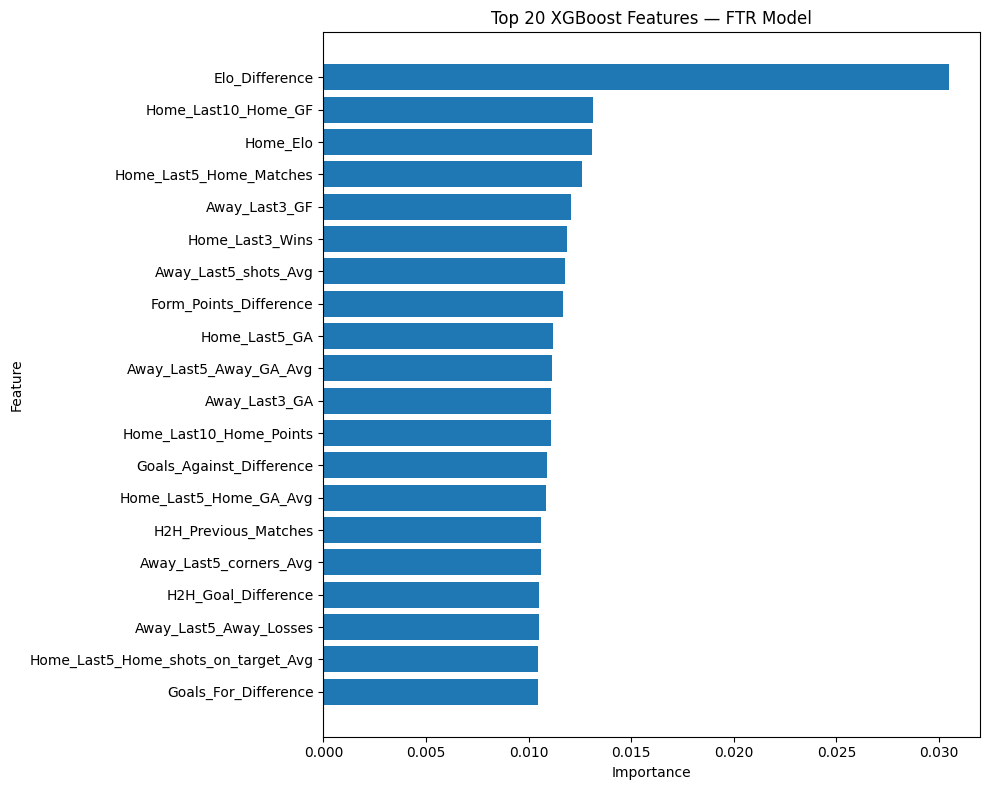

In [77]:
import matplotlib.pyplot as plt

top_features = importance_df.head(20).sort_values(
    'Importance'
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 XGBoost Features — FTR Model')

plt.tight_layout()
plt.show()

In [78]:
print(
    dict(
        zip(
            ftr_encoder.classes_,
            range(len(ftr_encoder.classes_))
        )
    )
)

{'A': 0, 'D': 1, 'H': 2}


In [79]:
# ============================================
# STEP 43: CLASS WEIGHTS
# ============================================

sample_weights = np.ones(len(y_train_encoded))

# Give draws more importance
draw_class = ftr_encoder.transform(['D'])[0]

sample_weights[
    y_train_encoded == draw_class
] = 1.5

print(
    "Draw samples:",
    np.sum(y_train_encoded == draw_class)
)

print(
    "Draw weight:",
    sample_weights[
        y_train_encoded == draw_class
    ][0]
)

Draw samples: 257
Draw weight: 1.5


In [80]:
# ============================================
# WEIGHTED XGBOOST
# ============================================

ftr_model_weighted = XGBClassifier(
    objective='multi:softprob',
    num_class=3,

    n_estimators=500,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    eval_metric='mlogloss',

    random_state=42,
    n_jobs=-1
)

ftr_model_weighted.fit(
    X_train,
    y_train_encoded,

    sample_weight=sample_weights,

    eval_set=[
        (X_train, y_train_encoded),
        (X_val, y_val_encoded)
    ],

    verbose=False
)

print("Weighted model trained.")

Weighted model trained.


In [81]:
y_val_weighted_pred = ftr_model_weighted.predict(X_val)
y_test_weighted_pred = ftr_model_weighted.predict(X_test)

y_val_weighted_prob = (
    ftr_model_weighted.predict_proba(X_val)
)

y_test_weighted_prob = (
    ftr_model_weighted.predict_proba(X_test)
)

In [82]:
print("================================")
print("WEIGHTED MODEL — VALIDATION")
print("================================")

print(
    "Accuracy:",
    accuracy_score(
        y_val_encoded,
        y_val_weighted_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val_encoded,
        y_val_weighted_pred
    )
)

print(
    "Log Loss:",
    log_loss(
        y_val_encoded,
        y_val_weighted_prob
    )
)

print(
    classification_report(
        y_val_encoded,
        y_val_weighted_pred,
        target_names=ftr_encoder.classes_
    )
)

WEIGHTED MODEL — VALIDATION
Accuracy: 0.48947368421052634
Balanced Accuracy: 0.4368198110133594
Log Loss: 1.1147706113560523
              precision    recall  f1-score   support

           A       0.55      0.45      0.50       132
           D       0.21      0.11      0.14        93
           H       0.52      0.75      0.61       155

    accuracy                           0.49       380
   macro avg       0.43      0.44      0.42       380
weighted avg       0.45      0.49      0.46       380



In [83]:
print("================================")
print("WEIGHTED MODEL — TEST")
print("================================")

print(
    "Accuracy:",
    accuracy_score(
        y_test_encoded,
        y_test_weighted_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_encoded,
        y_test_weighted_pred
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test_encoded,
        y_test_weighted_prob
    )
)

print(
    classification_report(
        y_test_encoded,
        y_test_weighted_pred,
        target_names=ftr_encoder.classes_
    )
)

WEIGHTED MODEL — TEST
Accuracy: 0.4368421052631579
Balanced Accuracy: 0.3885369287416071
Log Loss: 1.1445935315367435
              precision    recall  f1-score   support

           A       0.40      0.32      0.36       114
           D       0.27      0.12      0.17       104
           H       0.49      0.72      0.58       162

    accuracy                           0.44       380
   macro avg       0.38      0.39      0.37       380
weighted avg       0.40      0.44      0.40       380



In [84]:
# ============================================
# STEP 46: FEATURE SELECTION
# ============================================

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

top_30_features = importance_df.head(30)['Feature'].tolist()
top_50_features = importance_df.head(50)['Feature'].tolist()

print("Top 30 features:")
print(top_30_features)

print("\nTop 50 feature count:")
print(len(top_50_features))

Top 30 features:
['Elo_Difference', 'Home_Last10_Home_GF', 'Home_Elo', 'Home_Last5_Home_Matches', 'Away_Last3_GF', 'Home_Last3_Wins', 'Away_Last5_shots_Avg', 'Form_Points_Difference', 'Home_Last5_GA', 'Away_Last5_Away_GA_Avg', 'Away_Last3_GA', 'Home_Last10_Home_Points', 'Goals_Against_Difference', 'Home_Last5_Home_GA_Avg', 'H2H_Previous_Matches', 'Away_Last5_corners_Avg', 'H2H_Goal_Difference', 'Away_Last5_Away_Losses', 'Home_Last5_Home_shots_on_target_Avg', 'Goals_For_Difference', 'Away_Last10_GF', 'Away_Last5_Away_red_cards_Avg', 'Away_Last3_Points', 'Away_Last5_Away_GF_Avg', 'Home_Last5_Points', 'Home_Last5_Home_red_cards_Avg', 'Home_Last5_Home_Wins', 'Home_Last3_Home_Points', 'Away_Last3_Away_GA', 'Away_Last5_Away_GF']

Top 50 feature count:
50


In [85]:
# ============================================
# STEP 47: FEATURE SUBSETS
# ============================================

X_train_30 = train_df[top_30_features].copy()
X_val_30 = validation_df[top_30_features].copy()

X_train_50 = train_df[top_50_features].copy()
X_val_50 = validation_df[top_50_features].copy()

X_train_all = train_df[numeric_features].copy()
X_val_all = validation_df[numeric_features].copy()

print("All features:", X_train_all.shape)
print("Top 50:", X_train_50.shape)
print("Top 30:", X_train_30.shape)

All features: (1140, 105)
Top 50: (1140, 50)
Top 30: (1140, 30)


In [86]:
# ============================================
# STEP 48: TOP-50 XGBOOST
# ============================================

model_50 = XGBClassifier(
    objective='multi:softprob',
    num_class=3,

    n_estimators=500,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    eval_metric='mlogloss',

    random_state=42,
    n_jobs=-1
)

model_50.fit(
    X_train_50,
    y_train_encoded,

    eval_set=[
        (X_val_50, y_val_encoded)
    ],

    verbose=False
)

print("Top-50 model trained.")

Top-50 model trained.


In [87]:
# ============================================
# STEP 49
# ============================================

pred_50 = model_50.predict(X_val_50)
prob_50 = model_50.predict_proba(X_val_50)

print("TOP-50 VALIDATION")
print("============================")

print(
    "Accuracy:",
    accuracy_score(y_val_encoded, pred_50)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val_encoded,
        pred_50
    )
)

print(
    "Log Loss:",
    log_loss(
        y_val_encoded,
        prob_50
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_val_encoded,
        pred_50,
        target_names=ftr_encoder.classes_
    )
)

TOP-50 VALIDATION
Accuracy: 0.49736842105263157
Balanced Accuracy: 0.43996415770609315
Log Loss: 1.1135066840261096

Classification Report:
              precision    recall  f1-score   support

           A       0.55      0.42      0.47       132
           D       0.25      0.10      0.14        93
           H       0.51      0.81      0.63       155

    accuracy                           0.50       380
   macro avg       0.44      0.44      0.41       380
weighted avg       0.46      0.50      0.45       380



In [88]:
# ============================================
# STEP 50: TOP-30 XGBOOST
# ============================================

model_30 = XGBClassifier(
    objective='multi:softprob',
    num_class=3,

    n_estimators=500,
    learning_rate=0.03,

    max_depth=4,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    eval_metric='mlogloss',

    random_state=42,
    n_jobs=-1
)

model_30.fit(
    X_train_30,
    y_train_encoded,

    eval_set=[
        (X_val_30, y_val_encoded)
    ],

    verbose=False
)

pred_30 = model_30.predict(X_val_30)
prob_30 = model_30.predict_proba(X_val_30)

print("TOP-30 VALIDATION")
print("============================")

print(
    "Accuracy:",
    accuracy_score(
        y_val_encoded,
        pred_30
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val_encoded,
        pred_30
    )
)

print(
    "Log Loss:",
    log_loss(
        y_val_encoded,
        prob_30
    )
)

TOP-30 VALIDATION
Accuracy: 0.5078947368421053
Balanced Accuracy: 0.4454545454545455
Log Loss: 1.107412361609054


In [89]:
# ============================================
# STEP 51: ELO-ONLY BASELINE
# ============================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    log_loss,
    classification_report
)

# Simple Elo probability model
def elo_probabilities(home_elo, away_elo, home_advantage=60):
    """
    Convert Elo ratings into Home/Draw/Away probabilities.

    This is a simple baseline, not our final model.
    """

    rating_diff = home_elo + home_advantage - away_elo

    home_strength = 1 / (
        1 + 10 ** (-rating_diff / 400)
    )

    # Approximate draw probability
    draw_prob = 0.25 * (
        1 - abs(home_strength - 0.5)
    ) * 2

    draw_prob = np.clip(
        draw_prob,
        0.15,
        0.30
    )

    home_prob = home_strength * (1 - draw_prob)
    away_prob = (1 - home_strength) * (1 - draw_prob)

    return np.array([
        away_prob,
        draw_prob,
        home_prob
    ])

In [90]:
elo_val_prob = np.array([
    elo_probabilities(
        row['Home_Elo'],
        row['Away_Elo']
    )
    for _, row in validation_df.iterrows()
])

elo_test_prob = np.array([
    elo_probabilities(
        row['Home_Elo'],
        row['Away_Elo']
    )
    for _, row in test_df.iterrows()
])

In [91]:
print("Encoder classes:", ftr_encoder.classes_)
print("First Elo probabilities:", elo_val_prob[0])

Encoder classes: ['A' 'D' 'H']
First Elo probabilities: [0.21007242 0.3        0.48992758]


In [92]:
elo_val_pred = np.argmax(
    elo_val_prob,
    axis=1
)

elo_test_pred = np.argmax(
    elo_test_prob,
    axis=1
)

print("================================")
print("ELO BASELINE — VALIDATION")
print("================================")

print(
    "Accuracy:",
    accuracy_score(
        y_val_encoded,
        elo_val_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val_encoded,
        elo_val_pred
    )
)

print(
    "Log Loss:",
    log_loss(
        y_val_encoded,
        elo_val_prob
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_val_encoded,
        elo_val_pred,
        target_names=ftr_encoder.classes_
    )
)

ELO BASELINE — VALIDATION
Accuracy: 0.5263157894736842
Balanced Accuracy: 0.4563375692407951
Log Loss: 0.9997958961238704

Classification Report:
              precision    recall  f1-score   support

           A       0.56      0.53      0.54       132
           D       0.00      0.00      0.00        93
           H       0.51      0.84      0.64       155

    accuracy                           0.53       380
   macro avg       0.36      0.46      0.39       380
weighted avg       0.40      0.53      0.45       380



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [93]:
print("================================")
print("ELO BASELINE — TEST")
print("================================")

print(
    "Accuracy:",
    accuracy_score(
        y_test_encoded,
        elo_test_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_encoded,
        elo_test_pred
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test_encoded,
        elo_test_prob
    )
)

ELO BASELINE — TEST
Accuracy: 0.49473684210526314
Balanced Accuracy: 0.4353476283300844
Log Loss: 1.0228322961422636


In [94]:
# ============================================
# IMPROVED ELO: TRAINING DATA
# ============================================

elo_train = train_df.copy()

elo_train['Elo_Diff_Abs'] = (
    elo_train['Home_Elo'] -
    elo_train['Away_Elo']
).abs()

elo_train['Elo_Diff'] = (
    elo_train['Home_Elo'] -
    elo_train['Away_Elo']
)

print(
    elo_train[
        [
            'HomeTeam',
            'AwayTeam',
            'Home_Elo',
            'Away_Elo',
            'Elo_Diff',
            'Elo_Diff_Abs',
            'FTR'
        ]
    ].head()
)

     HomeTeam        AwayTeam  Home_Elo  Away_Elo  Elo_Diff  Elo_Diff_Abs FTR
0   Brentford         Arsenal    1500.0    1500.0       0.0           0.0   H
1  Man United           Leeds    1500.0    1500.0       0.0           0.0   H
2     Burnley        Brighton    1500.0    1500.0       0.0           0.0   A
3     Chelsea  Crystal Palace    1500.0    1500.0       0.0           0.0   H
4     Everton     Southampton    1500.0    1500.0       0.0           0.0   H


In [95]:
# ============================================
# DRAW RATE BY ELO DIFFERENCE
# ============================================

elo_train['Elo_Band'] = pd.cut(
    elo_train['Elo_Diff_Abs'],
    bins=[
        -1,
        25,
        50,
        75,
        100,
        150,
        200,
        np.inf
    ],
    labels=[
        '0-25',
        '25-50',
        '50-75',
        '75-100',
        '100-150',
        '150-200',
        '200+'
    ]
)

draw_rates = (
    elo_train
    .groupby('Elo_Band', observed=False)
    .agg(
        Matches=('FTR', 'size'),
        Draws=('FTR', lambda x: (x == 'D').sum()),
        Draw_Rate=('FTR', lambda x: (x == 'D').mean())
    )
)

print(draw_rates)

          Matches  Draws  Draw_Rate
Elo_Band                           
0-25          240     61   0.254167
25-50         222     55   0.247748
50-75         167     35   0.209581
75-100        121     30   0.247934
100-150       195     44   0.225641
150-200       100     21   0.210000
200+           95     11   0.115789


In [96]:
from sklearn.linear_model import LogisticRegression

elo_features = [
    'Home_Elo',
    'Away_Elo',
    'Elo_Difference'
]

elo_classifier = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000,
    C=1.0
)

elo_classifier.fit(
    train_df[elo_features],
    y_train_encoded
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [97]:
elo_val_prob = elo_classifier.predict_proba(
    validation_df[elo_features]
)

elo_test_prob = elo_classifier.predict_proba(
    test_df[elo_features]
)

In [98]:
elo_lr_val_pred = np.argmax(
    elo_val_prob,
    axis=1
)

elo_lr_test_pred = np.argmax(
    elo_test_prob,
    axis=1
)

print("IMPROVED ELO — VALIDATION")
print("==============================")

print(
    "Accuracy:",
    accuracy_score(
        y_val_encoded,
        elo_lr_val_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_val_encoded,
        elo_lr_val_pred
    )
)

print(
    "Log Loss:",
    log_loss(
        y_val_encoded,
        elo_val_prob
    )
)

print(
    classification_report(
        y_val_encoded,
        elo_lr_val_pred,
        target_names=ftr_encoder.classes_
    )
)

IMPROVED ELO — VALIDATION
Accuracy: 0.5394736842105263
Balanced Accuracy: 0.4708374063212773
Log Loss: 0.9954093932538335
              precision    recall  f1-score   support

           A       0.56      0.61      0.58       132
           D       0.00      0.00      0.00        93
           H       0.53      0.81      0.64       155

    accuracy                           0.54       380
   macro avg       0.36      0.47      0.41       380
weighted avg       0.41      0.54      0.46       380



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [99]:
print("IMPROVED ELO — TEST")
print("==============================")

print(
    "Accuracy:",
    accuracy_score(
        y_test_encoded,
        elo_lr_test_pred
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_test_encoded,
        elo_lr_test_pred
    )
)

print(
    "Log Loss:",
    log_loss(
        y_test_encoded,
        elo_test_prob
    )
)

IMPROVED ELO — TEST
Accuracy: 0.5026315789473684
Balanced Accuracy: 0.4449859215941087
Log Loss: 1.0452396112955595


In [100]:
# ============================================
# STEP 57: COMPARE ELO MODELS
# ============================================

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print("\nVALIDATION")
print("-" * 60)

print(f"Original Elo Accuracy:       {0.5263157895:.4f}")
print(f"Original Elo Balanced Acc:   {0.4563375692:.4f}")
print(f"Original Elo Log Loss:       {0.9997958961:.4f}")

print(f"Improved Elo Accuracy:       {accuracy_score(y_val_encoded, elo_lr_val_pred):.4f}")
print(f"Improved Elo Balanced Acc:   {balanced_accuracy_score(y_val_encoded, elo_lr_val_pred):.4f}")
print(f"Improved Elo Log Loss:       {log_loss(y_val_encoded, elo_val_prob):.4f}")

print("\nTEST")
print("-" * 60)

print(f"Original Elo Accuracy:       {0.4947368421:.4f}")
print(f"Original Elo Balanced Acc:   {0.4353476283:.4f}")
print(f"Original Elo Log Loss:       {1.0228322963:.4f}")

print(f"Improved Elo Accuracy:       {accuracy_score(y_test_encoded, elo_lr_test_pred):.4f}")
print(f"Improved Elo Balanced Acc:   {balanced_accuracy_score(y_test_encoded, elo_lr_test_pred):.4f}")
print(f"Improved Elo Log Loss:       {log_loss(y_test_encoded, elo_test_prob):.4f}")

MODEL COMPARISON

VALIDATION
------------------------------------------------------------
Original Elo Accuracy:       0.5263
Original Elo Balanced Acc:   0.4563
Original Elo Log Loss:       0.9998
Improved Elo Accuracy:       0.5395
Improved Elo Balanced Acc:   0.4708
Improved Elo Log Loss:       0.9954

TEST
------------------------------------------------------------
Original Elo Accuracy:       0.4947
Original Elo Balanced Acc:   0.4353
Original Elo Log Loss:       1.0228
Improved Elo Accuracy:       0.5026
Improved Elo Balanced Acc:   0.4450
Improved Elo Log Loss:       1.0452


In [101]:
print("\nIMPROVED ELO PREDICTION DISTRIBUTION")
print("-" * 60)

print(
    pd.Series(
        ftr_encoder.inverse_transform(elo_lr_test_pred)
    ).value_counts()
)


IMPROVED ELO PREDICTION DISTRIBUTION
------------------------------------------------------------
H    248
A    132
Name: count, dtype: int64


In [102]:
import numpy as np
import pandas as pd
from scipy.stats import poisson

In [103]:
# ============================================
# STEP 58: BUILD NORMALIZED POISSON FEATURES
# ============================================

from collections import defaultdict

poisson_df = features_df.sort_values(
    ['Date', 'Season_Match_Number']
).copy()

# --------------------------------------------
# TRAINING DATA ONLY FOR LEAGUE AVERAGES
# --------------------------------------------

poisson_train = poisson_df[
    poisson_df['Season'].isin(train_seasons)
].copy()

league_home_goals = poisson_train['FTHG'].mean()
league_away_goals = poisson_train['FTAG'].mean()

print("League average home goals:", league_home_goals)
print("League average away goals:", league_away_goals)


# --------------------------------------------
# TEAM HISTORY
# --------------------------------------------

team_history = defaultdict(
    lambda: {
        'gf': [],
        'ga': [],
        'home_gf': [],
        'home_ga': [],
        'away_gf': [],
        'away_ga': []
    }
)

poisson_rows = []


def safe_mean(values, default):
    if len(values) == 0:
        return default
    return np.mean(values)


# --------------------------------------------
# PROCESS MATCHES CHRONOLOGICALLY
# --------------------------------------------

for _, row in poisson_df.iterrows():

    home = row['HomeTeam']
    away = row['AwayTeam']

    h = team_history[home]
    a = team_history[away]

    # Previous overall performance
    home_gf = safe_mean(
        h['gf'],
        league_home_goals
    )

    home_ga = safe_mean(
        h['ga'],
        league_away_goals
    )

    away_gf = safe_mean(
        a['gf'],
        league_away_goals
    )

    away_ga = safe_mean(
        a['ga'],
        league_home_goals
    )

    # ----------------------------------------
    # NORMALIZED ATTACK STRENGTH
    # ----------------------------------------

    home_attack = (
        home_gf / league_home_goals
    )

    away_attack = (
        away_gf / league_away_goals
    )

    # ----------------------------------------
    # NORMALIZED DEFENSIVE STRENGTH
    # LOWER = BETTER DEFENCE
    # ----------------------------------------

    home_defense = (
        home_ga / league_away_goals
    )

    away_defense = (
        away_ga / league_home_goals
    )

    poisson_rows.append({

        'Date': row['Date'],

        'Season': row['Season'],

        'Season_Match_Number':
            row['Season_Match_Number'],

        'HomeTeam': home,

        'AwayTeam': away,

        'Home_Attack_Strength':
            home_attack,

        'Home_Defense_Strength':
            home_defense,

        'Away_Attack_Strength':
            away_attack,

        'Away_Defense_Strength':
            away_defense,

        'FTHG': row['FTHG'],

        'FTAG': row['FTAG'],

        'FTR': row['FTR']
    })

    # ----------------------------------------
    # UPDATE AFTER MATCH
    # ----------------------------------------

    h['gf'].append(row['FTHG'])
    h['ga'].append(row['FTAG'])

    h['home_gf'].append(row['FTHG'])
    h['home_ga'].append(row['FTAG'])

    a['gf'].append(row['FTAG'])
    a['ga'].append(row['FTHG'])

    a['away_gf'].append(row['FTAG'])
    a['away_ga'].append(row['FTHG'])


poisson_features_df = pd.DataFrame(
    poisson_rows
)

print(
    "\nPoisson feature dataset:",
    poisson_features_df.shape
)

print(
    poisson_features_df.head(15)
)

League average home goals: 1.6491228070175439
League average away goals: 1.3342105263157895

Poisson feature dataset: (1900, 12)
         Date     Season  Season_Match_Number        HomeTeam        AwayTeam  \
0  2021-08-13  2021/2022                    1       Brentford         Arsenal   
1  2021-08-14  2021/2022                    2      Man United           Leeds   
2  2021-08-14  2021/2022                    3         Burnley        Brighton   
3  2021-08-14  2021/2022                    4         Chelsea  Crystal Palace   
4  2021-08-14  2021/2022                    5         Everton     Southampton   
5  2021-08-14  2021/2022                    6       Leicester          Wolves   
6  2021-08-14  2021/2022                    7         Watford     Aston Villa   
7  2021-08-14  2021/2022                    8         Norwich       Liverpool   
8  2021-08-15  2021/2022                    9       Newcastle        West Ham   
9  2021-08-15  2021/2022                   10       Tottenham

In [104]:
# ============================================
# STEP 59: SMOOTH POISSON TEAM STRENGTHS
# ============================================

poisson_features_df = poisson_features_df.copy()

# Prevent zero/extreme strengths
MIN_STRENGTH = 0.25
MAX_STRENGTH = 2.50

strength_columns = [
    'Home_Attack_Strength',
    'Home_Defense_Strength',
    'Away_Attack_Strength',
    'Away_Defense_Strength'
]

for col in strength_columns:
    poisson_features_df[col] = (
        poisson_features_df[col]
        .clip(
            lower=MIN_STRENGTH,
            upper=MAX_STRENGTH
        )
    )

print(
    poisson_features_df[
        [
            'HomeTeam',
            'AwayTeam',
            'Home_Attack_Strength',
            'Home_Defense_Strength',
            'Away_Attack_Strength',
            'Away_Defense_Strength'
        ]
    ].head(15)
)

          HomeTeam        AwayTeam  Home_Attack_Strength  \
0        Brentford         Arsenal              1.000000   
1       Man United           Leeds              1.000000   
2          Burnley        Brighton              1.000000   
3          Chelsea  Crystal Palace              1.000000   
4          Everton     Southampton              1.000000   
5        Leicester          Wolves              1.000000   
6          Watford     Aston Villa              1.000000   
7          Norwich       Liverpool              1.000000   
8        Newcastle        West Ham              1.000000   
9        Tottenham        Man City              1.000000   
10       Liverpool         Burnley              1.819149   
11        Man City         Norwich              0.250000   
12           Leeds         Everton              0.606383   
13     Aston Villa       Newcastle              1.212766   
14  Crystal Palace       Brentford              0.250000   

    Home_Defense_Strength  Away_Attack_

In [105]:
# ============================================
# STEP 60: CALCULATE EXPECTED GOALS (λ)
# ============================================

poisson_features_df['Expected_Home_Goals'] = (
    league_home_goals
    *
    poisson_features_df['Home_Attack_Strength']
    *
    poisson_features_df['Away_Defense_Strength']
)

poisson_features_df['Expected_Away_Goals'] = (
    league_away_goals
    *
    poisson_features_df['Away_Attack_Strength']
    *
    poisson_features_df['Home_Defense_Strength']
)

print(
    poisson_features_df[
        [
            'Date',
            'HomeTeam',
            'AwayTeam',
            'Expected_Home_Goals',
            'Expected_Away_Goals',
            'FTHG',
            'FTAG'
        ]
    ].head(20)
)

         Date        HomeTeam        AwayTeam  Expected_Home_Goals  \
0  2021-08-13       Brentford         Arsenal             1.649123   
1  2021-08-14      Man United           Leeds             1.649123   
2  2021-08-14         Burnley        Brighton             1.649123   
3  2021-08-14         Chelsea  Crystal Palace             1.649123   
4  2021-08-14         Everton     Southampton             1.649123   
5  2021-08-14       Leicester          Wolves             1.649123   
6  2021-08-14         Watford     Aston Villa             1.649123   
7  2021-08-14         Norwich       Liverpool             1.649123   
8  2021-08-15       Newcastle        West Ham             1.649123   
9  2021-08-15       Tottenham        Man City             1.649123   
10 2021-08-21       Liverpool         Burnley             3.638298   
11 2021-08-21        Man City         Norwich             0.750000   
12 2021-08-21           Leeds         Everton             0.606383   
13 2021-08-21     As

In [106]:
# ============================================
# STEP 61: SMOOTHED POISSON MODEL
# ============================================

from collections import defaultdict
import numpy as np
import pandas as pd

poisson_df = features_df.sort_values(
    ['Date', 'Season_Match_Number']
).copy()

# League averages from TRAINING seasons only
poisson_train = poisson_df[
    poisson_df['Season'].isin(train_seasons)
].copy()

league_home_goals = poisson_train['FTHG'].mean()
league_away_goals = poisson_train['FTAG'].mean()

print("League home goals:", league_home_goals)
print("League away goals:", league_away_goals)


# ------------------------------------------------
# PRIOR STRENGTH
# ------------------------------------------------

# Number of previous matches needed before
# strongly trusting team-specific data
PRIOR_MATCHES = 8


team_history = defaultdict(
    lambda: {
        'gf': [],
        'ga': []
    }
)


poisson_rows = []


def smoothed_mean(values, league_mean):
    """
    Bayesian-style shrinkage toward league average.
    """

    n = len(values)

    if n == 0:
        return league_mean

    team_mean = np.mean(values)

    return (
        team_mean * n
        +
        league_mean * PRIOR_MATCHES
    ) / (
        n + PRIOR_MATCHES
    )


for _, row in poisson_df.iterrows():

    home = row['HomeTeam']
    away = row['AwayTeam']

    h = team_history[home]
    a = team_history[away]

    # ----------------------------------------
    # PRE-MATCH GOAL RATES
    # ----------------------------------------

    home_gf = smoothed_mean(
        h['gf'],
        league_home_goals
    )

    home_ga = smoothed_mean(
        h['ga'],
        league_away_goals
    )

    away_gf = smoothed_mean(
        a['gf'],
        league_away_goals
    )

    away_ga = smoothed_mean(
        a['ga'],
        league_home_goals
    )

    # ----------------------------------------
    # ATTACK STRENGTH
    # ----------------------------------------

    home_attack = (
        home_gf / league_home_goals
    )

    away_attack = (
        away_gf / league_away_goals
    )

    # ----------------------------------------
    # DEFENSIVE STRENGTH
    # ----------------------------------------

    home_defense = (
        home_ga / league_away_goals
    )

    away_defense = (
        away_ga / league_home_goals
    )

    # ----------------------------------------
    # KEEP STRENGTHS REASONABLE
    # ----------------------------------------

    home_attack = np.clip(
        home_attack,
        0.50,
        1.80
    )

    away_attack = np.clip(
        away_attack,
        0.50,
        1.80
    )

    home_defense = np.clip(
        home_defense,
        0.50,
        1.80
    )

    away_defense = np.clip(
        away_defense,
        0.50,
        1.80
    )

    # ----------------------------------------
    # EXPECTED GOALS
    # ----------------------------------------

    expected_home = (
        league_home_goals
        *
        home_attack
        *
        away_defense
    )

    expected_away = (
        league_away_goals
        *
        away_attack
        *
        home_defense
    )

    # Final safety limits
    expected_home = np.clip(
        expected_home,
        0.25,
        4.00
    )

    expected_away = np.clip(
        expected_away,
        0.25,
        4.00
    )

    poisson_rows.append({

        'Date': row['Date'],
        'Season': row['Season'],
        'Season_Match_Number':
            row['Season_Match_Number'],

        'HomeTeam': home,
        'AwayTeam': away,

        'Home_Attack_Strength':
            home_attack,

        'Home_Defense_Strength':
            home_defense,

        'Away_Attack_Strength':
            away_attack,

        'Away_Defense_Strength':
            away_defense,

        'Expected_Home_Goals':
            expected_home,

        'Expected_Away_Goals':
            expected_away,

        'FTHG': row['FTHG'],
        'FTAG': row['FTAG'],
        'FTR': row['FTR']
    })

    # ----------------------------------------
    # UPDATE AFTER MATCH
    # ----------------------------------------

    h['gf'].append(row['FTHG'])
    h['ga'].append(row['FTAG'])

    a['gf'].append(row['FTAG'])
    a['ga'].append(row['FTHG'])


poisson_features_df = pd.DataFrame(
    poisson_rows
)

print(
    "\nNew Poisson dataset shape:",
    poisson_features_df.shape
)

print(
    poisson_features_df[
        [
            'Date',
            'HomeTeam',
            'AwayTeam',
            'Expected_Home_Goals',
            'Expected_Away_Goals',
            'FTHG',
            'FTAG'
        ]
    ].head(20)
)

League home goals: 1.6491228070175439
League away goals: 1.3342105263157895

New Poisson dataset shape: (1900, 14)
         Date        HomeTeam        AwayTeam  Expected_Home_Goals  \
0  2021-08-13       Brentford         Arsenal             1.649123   
1  2021-08-14      Man United           Leeds             1.649123   
2  2021-08-14         Burnley        Brighton             1.649123   
3  2021-08-14         Chelsea  Crystal Palace             1.649123   
4  2021-08-14         Everton     Southampton             1.649123   
5  2021-08-14       Leicester          Wolves             1.649123   
6  2021-08-14         Watford     Aston Villa             1.649123   
7  2021-08-14         Norwich       Liverpool             1.649123   
8  2021-08-15       Newcastle        West Ham             1.649123   
9  2021-08-15       Tottenham        Man City             1.649123   
10 2021-08-21       Liverpool         Burnley             1.841755   
11 2021-08-21        Man City         Norwich